# Demo 13 - Heston calibration versus local-vol/eSSVI proxy

This notebook is the final Capstone 3 comparison artifact. It keeps the demo layer thin: build a deterministic target quote set, calibrate Heston once, call `run_heston_vs_local_vol_comparison(...)`, and display the diagnostic tables without rebuilding pricing, eSSVI, residual, bucket, or tradeoff logic in the notebook.

REVIEW: This comparison uses the repo-native eSSVI nodal implied surface as a local-vol-facing proxy. It does not run direct Dupire/PDE local-vol repricing. Direct PDE repricing should be audited separately if the capstone conclusion depends on pathwise local-vol pricing.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

for candidate in (Path.cwd(), *Path.cwd().parents):
    src = candidate / "src"
    if (src / "option_pricing").exists():
        sys.path.insert(0, str(src))
        break

## Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from option_pricing.diagnostics.heston import (
    build_synthetic_heston_quote_set,
    plot_heston_model_comparison_error_buckets,
    plot_heston_model_comparison_iv_residual_heatmap,
    plot_heston_model_comparison_smile_overlay,
    plot_heston_model_comparison_train_heldout,
    run_heston_vs_local_vol_comparison,
)
from option_pricing.models.heston.calibration import calibrate_heston_multistart
from option_pricing.models.heston.calibration.bounds import HestonCalibrationBounds
from option_pricing.models.heston.params import HESTON_PARAM_NAMES, HestonParams
from option_pricing.numerics.quadrature import QuadratureConfig
from option_pricing.vol.ssvi import ESSVICalibrationConfig

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 88)

## Common target quote set

The target is a small deterministic Heston-generated vanilla grid with a fixed random seed for quote noise. The held-out split is defined once and passed into the diagnostics so both model rows carry the same `train` or `held_out` label.

In [3]:
true_params = HestonParams(kappa=1.7, vbar=0.04, eta=0.55, rho=-0.55, v=0.045)
quad_cfg = QuadratureConfig(u_max=50.0, n_panels=6, nodes_per_panel=6)

quotes = build_synthetic_heston_quote_set(
    market=None,
    true_params=true_params,
    expiries=np.array([0.5, 1.0, 2.0], dtype=np.float64),
    log_moneyness=np.array([-0.12, -0.06, 0.0, 0.06, 0.12], dtype=np.float64),
    backend="gauss_legendre",
    quad_cfg=quad_cfg,
    random_seed=123,
    noise_vol_bps=1.0,
)

held_out_mask = np.zeros(quotes.n_quotes, dtype=np.bool_)
held_out_mask[4::5] = True

pd.DataFrame(
    {
        "quote_index": np.arange(quotes.n_quotes, dtype=np.int64),
        "expiry": quotes.expiry,
        "log_moneyness": quotes.log_moneyness,
        "strike": quotes.strike,
        "market_iv": quotes.iv_mid,
        "market_price": quotes.mid,
        "sample": np.where(held_out_mask, "held_out", "train"),
    }
)

,quote_index,expiry,log_moneyness,strike,market_iv,market_price,sample
0,0,0.5,-0.12,89.136614,0.224923,13.220707,train
1,1,0.5,-0.06,94.648515,0.206940,9.020301,train
2,2,0.5,0.00,100.501252,0.189633,5.332102,train
3,3,0.5,0.06,106.715902,0.174645,2.564108,train
4,4,0.5,0.12,113.314845,0.167277,1.014125,held_out
5,5,1.0,-0.12,89.583414,0.209612,14.705246,train
6,6,1.0,-0.06,95.122942,0.195997,10.788173,train
7,7,1.0,0.00,101.005017,0.183191,7.261646,train
8,8,1.0,0.06,107.250818,0.171924,4.372952,train
9,9,1.0,0.12,113.882838,0.164036,2.342127,held_out


## Heston calibration

The notebook uses the library multistart calibrator and then hands the result to the comparison diagnostic. The optimizer settings are intentionally small and deterministic for demo runtime.

In [4]:
bounds = HestonCalibrationBounds()
heston_fit = calibrate_heston_multistart(
    quotes=quotes,
    objective_type="vega_scaled_price",
    bounds=bounds,
    quad_cfg=quad_cfg,
    max_seeds=6,
    parameter_transform="bounded",
    loss="linear",
    max_nfev=100,
)

pd.DataFrame(
    {
        "parameter": HESTON_PARAM_NAMES,
        "true": true_params.as_array(),
        "fitted": heston_fit.best_params.as_array(),
        "absolute_error": np.abs(heston_fit.best_params.as_array() - true_params.as_array()),
    }
)

,parameter,true,fitted,absolute_error
0,kappa,1.700,1.691300,0.008700
1,vbar,0.040,0.039987,0.000013
2,eta,0.550,0.547584,0.002416
3,rho,-0.550,-0.549823,0.000177
4,v,0.045,0.044959,0.000041


In [5]:
pd.DataFrame(
    [
        {
            "seed_index": heston_fit.best_run.seed_index,
            "success": heston_fit.best_run.success,
            "cost": heston_fit.best_run.cost,
            "optimality": heston_fit.best_run.optimality,
            "nfev": heston_fit.best_run.nfev,
            "message": heston_fit.best_run.message,
        }
    ]
)

,seed_index,success,cost,optimality,nfev,message
0,3,True,4.283830e-08,5.334496e-12,9,`gtol` termination condition is satisfied.


## Heston versus local-vol/eSSVI proxy

The comparison object is the source of truth for residual rows, summary metrics, held-out splits, buckets, tradeoffs, and limitation notes.

In [6]:
comparison = run_heston_vs_local_vol_comparison(
    quotes=quotes,
    heston_fit=heston_fit,
    held_out_mask=held_out_mask,
    heston_quad_cfg=quad_cfg,
    essvi_cfg=ESSVICalibrationConfig(max_nfev=800),
)

assert set(comparison.tables) >= {
    "fit_errors",
    "error_summary",
    "held_out_comparison",
    "tradeoff_summary",
}
assert comparison.meta["direct_local_vol_pde_repricing"] is False

comparison.meta

{'diagnostic': 'heston_vs_local_vol_comparison',
 'models': ['Heston', 'ESSVI local-vol proxy'],
 'quote_count': 15,
 'train_quote_count': 12,
 'held_out_quote_count': 3,
 'expiry_count': 3,
 'log_moneyness_count': 5,
 'held_out_mask_provided': True,
 'sample_labels': ['train', 'held_out'],
 'comparison_target': 'same HestonQuoteSet quotes repriced by both models',
 'local_vol_proxy_kind': 'essvi_nodal_implied_surface',
 'local_vol_proxy': 'ESSVINodalSurface repricing from calibrate_essvi',
 'direct_local_vol_pde_repricing': False,
 'local_vol_fit_source': 'computed',
 'heston_backend_config': {'backend': 'gauss_legendre',
  'config_resolution': 'explicit_quad_cfg',
  'u_max': 50.0,
  'n_panels': 6,
  'nodes_per_panel': 6,
  'panel_spacing': 'uniform',
  'cluster_strength': 2.0},
 'essvi_success': True,
 'essvi_nfev': 12,
 'essvi_cost': 6.127277199997777e-05,
 'notes': ['REVIEW: This comparison uses the repo-native eSSVI nodal implied surface as a local-vol-facing proxy. It does not ru

## Diagnostic plots

These figures consume the packaged comparison diagnostics. The notebook does not rebuild residuals, buckets, train/held-out summaries, or model-pricing data.

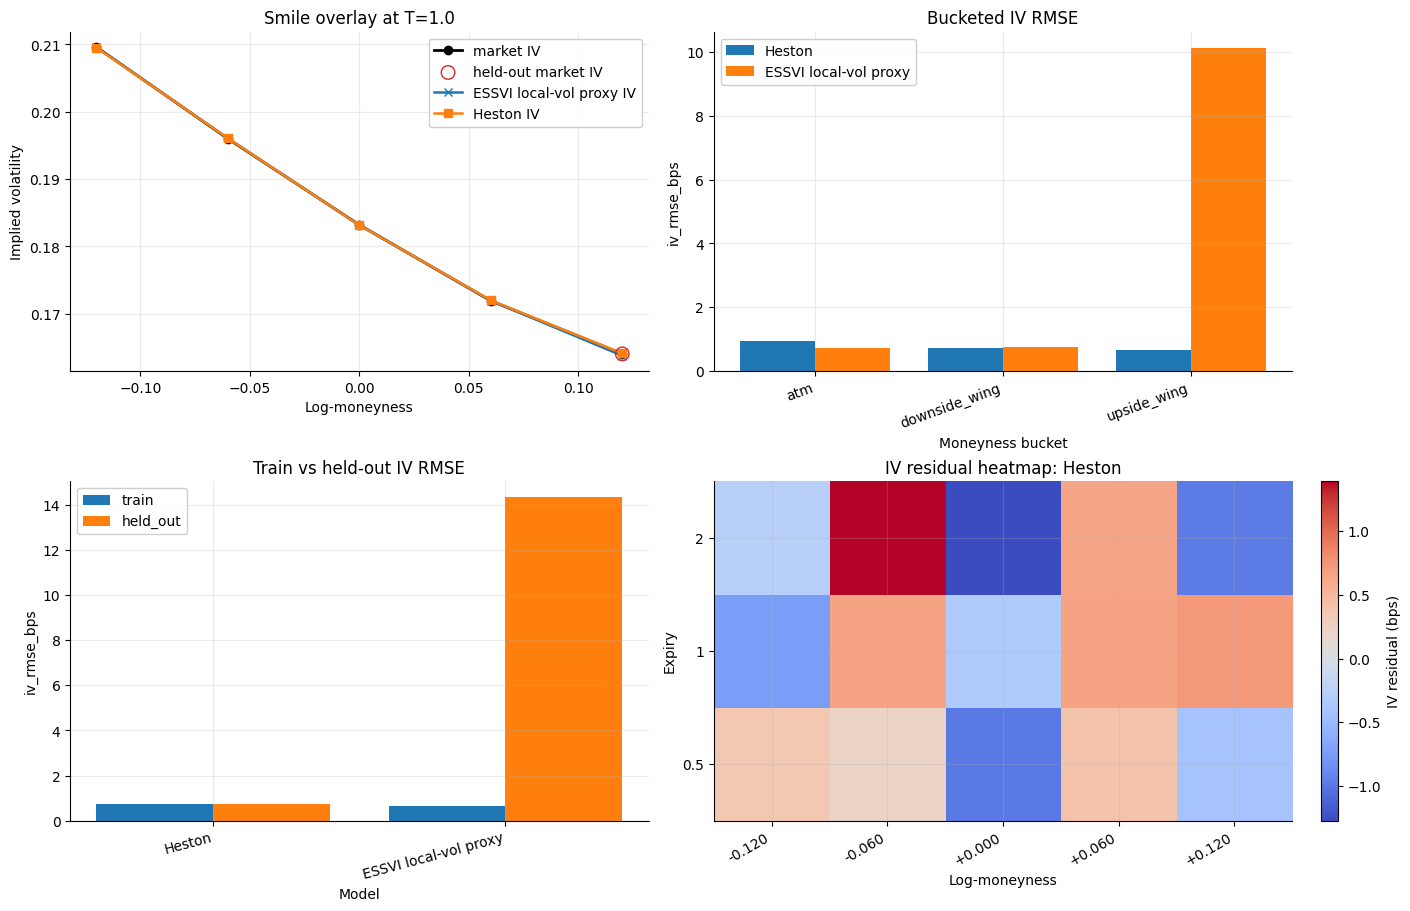

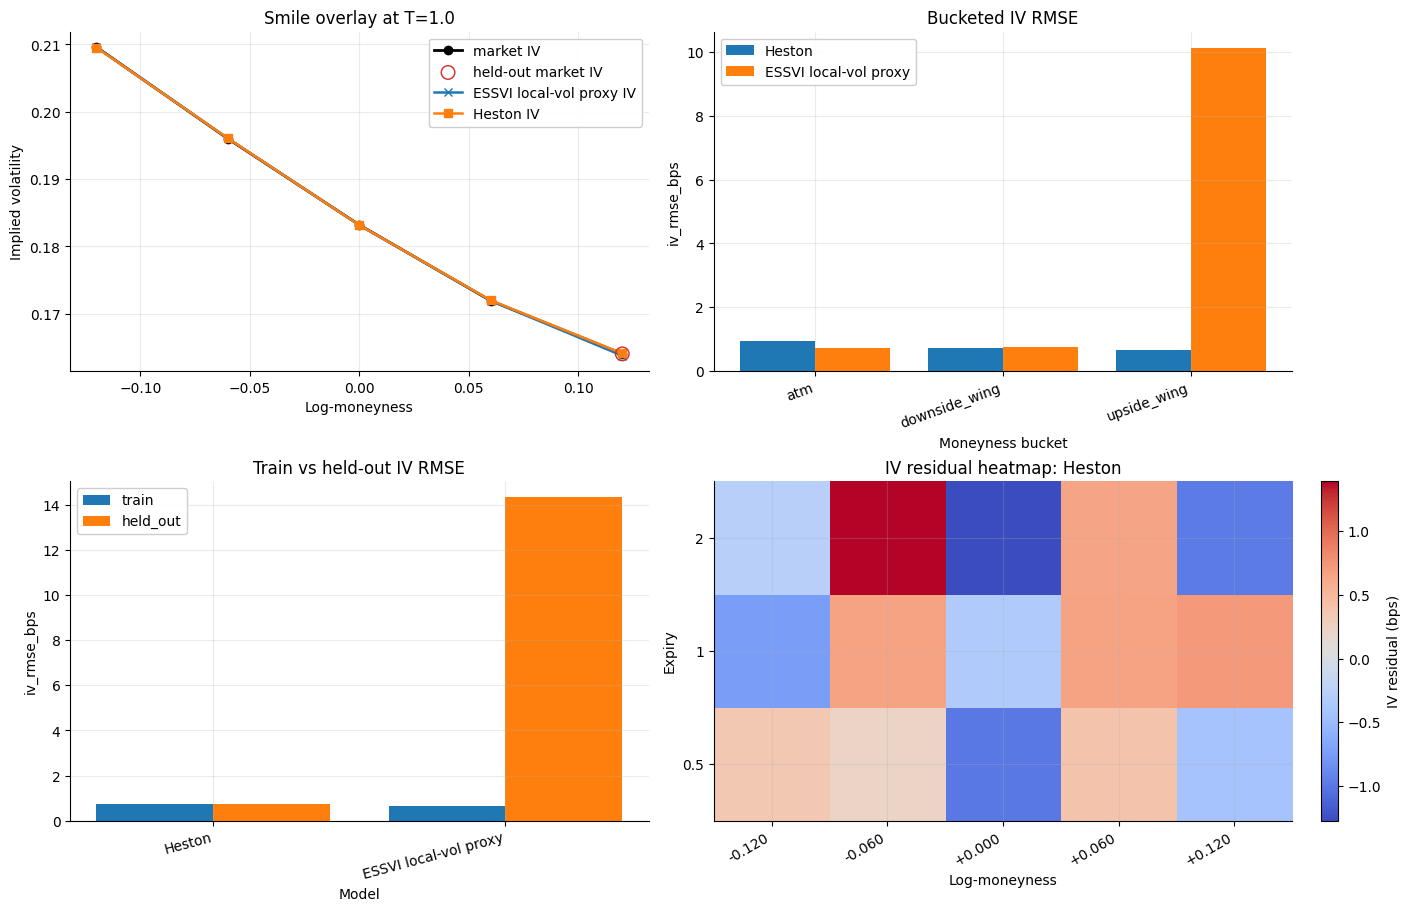

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14.0, 9.0), constrained_layout=True)

plot_heston_model_comparison_smile_overlay(
    comparison,
    expiry=1.0,
    ax=axes[0, 0],
    title="Smile overlay at T=1.0",
)
plot_heston_model_comparison_error_buckets(
    comparison,
    metric="iv_rmse_bps",
    ax=axes[0, 1],
    title="Bucketed IV RMSE",
)
plot_heston_model_comparison_train_heldout(
    comparison,
    metric="iv_rmse_bps",
    ax=axes[1, 0],
    title="Train vs held-out IV RMSE",
)
plot_heston_model_comparison_iv_residual_heatmap(
    comparison,
    model="Heston",
    ax=axes[1, 1],
    title="IV residual heatmap",
)

fig


## Side-by-side residual heatmaps

The long-form `fit_errors` table is heatmap-ready for each model. This side-by-side view makes maturity and moneyness structure visible without any notebook-local residual logic.

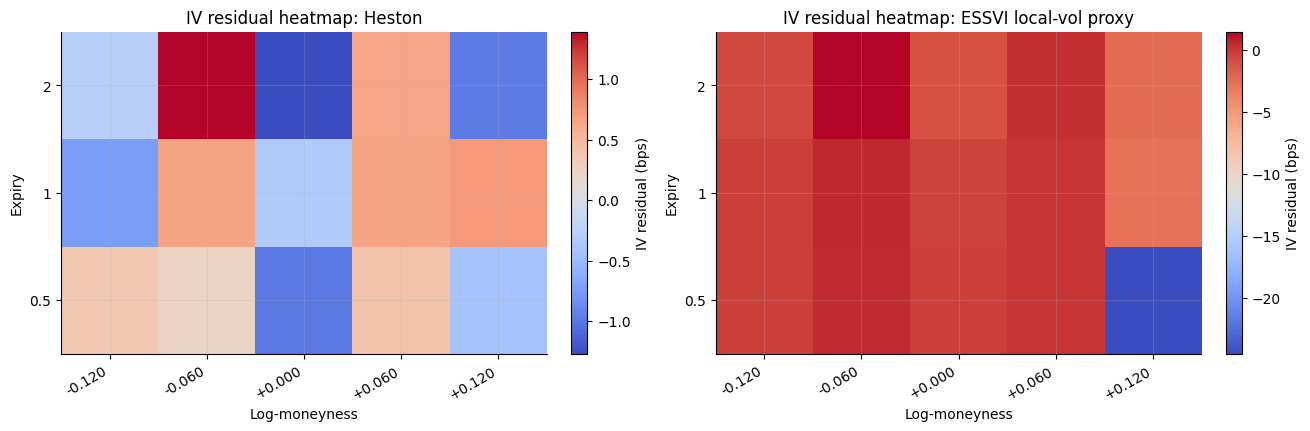

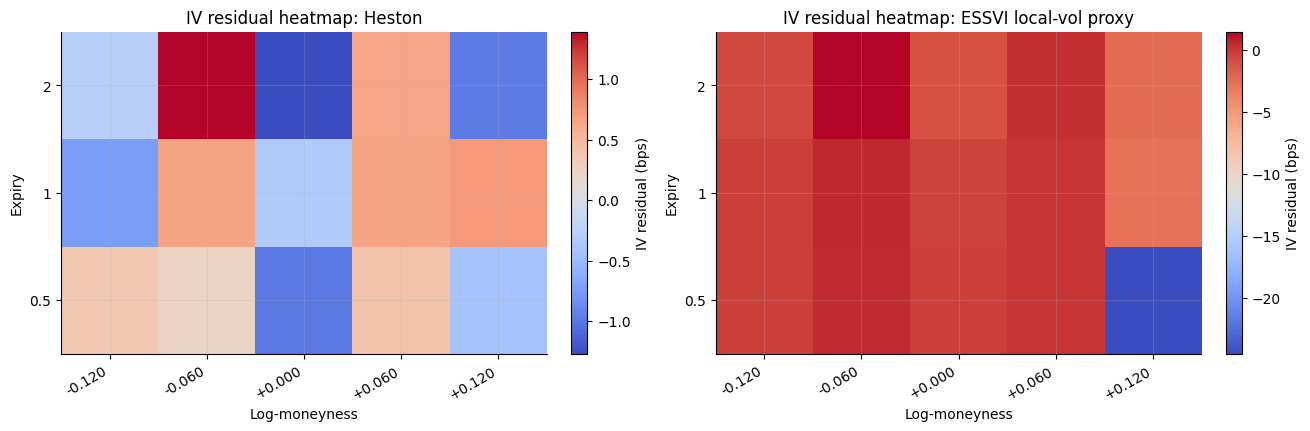

In [8]:
model_names = list(comparison.meta["models"])
fig, axes = plt.subplots(
    1,
    len(model_names),
    figsize=(6.5 * len(model_names), 4.2),
    constrained_layout=True,
)

for ax, model_name in zip(np.atleast_1d(axes), model_names, strict=True):
    plot_heston_model_comparison_iv_residual_heatmap(
        comparison,
        model=model_name,
        ax=ax,
        title="IV residual heatmap",
    )

fig


## Fit quality and held-out split

In [9]:
comparison.tables["held_out_comparison"]

,model,sample,n_quotes,price_rmse,price_mae,price_max_abs,iv_rmse_bps,iv_mae_bps,iv_max_abs_bps
0,Heston,train,12,0.003497,0.002747,0.007295,0.759319,0.663268,1.392438
1,Heston,held_out,3,0.003239,0.002707,0.005050,0.741366,0.705193,0.975258
2,ESSVI local-vol proxy,train,12,0.003196,0.002249,0.007660,0.647087,0.515972,1.461956
3,ESSVI local-vol proxy,held_out,3,0.026628,0.021679,0.043414,14.325681,9.914866,24.537589


In [10]:
comparison.tables["error_summary"]

,model,bucket,n_quotes,price_rmse,price_mae,price_max_abs,iv_rmse_bps,iv_mae_bps,iv_max_abs_bps
0,Heston,all,15,0.003447,0.002739,0.007295,0.755763,0.671653,1.392438
1,Heston,atm,3,0.004451,0.003737,0.007053,0.954780,0.871400,1.273061
2,Heston,downside_wing,6,0.003347,0.002442,0.007295,0.728288,0.608094,1.392438
3,Heston,upside_wing,6,0.002932,0.002537,0.005050,0.664633,0.635337,0.975258
4,ESSVI local-vol proxy,all,15,0.012247,0.006135,0.043414,6.432729,2.395751,24.537589
5,ESSVI local-vol proxy,atm,3,0.003767,0.002884,0.006284,0.713069,0.605842,1.134300
6,ESSVI local-vol proxy,downside_wing,6,0.003569,0.002642,0.007660,0.749537,0.640820,1.461956
7,ESSVI local-vol proxy,upside_wing,6,0.018845,0.011253,0.043414,10.130843,5.045636,24.537589


## Heatmap-ready residual rows

The diagnostic returns quote-level residual rows in long form, including model name, expiry, log-moneyness, bucket, and sample label. A plotting notebook can pivot this table without recomputing either model.

In [11]:
comparison.tables["fit_errors"].loc[
    :,
    [
        "model",
        "quote_index",
        "expiry",
        "log_moneyness",
        "moneyness_bucket",
        "sample",
        "market_iv",
        "model_iv",
        "iv_residual_bps",
        "price_residual",
    ],
]

,model,quote_index,expiry,log_moneyness,moneyness_bucket,sample,market_iv,model_iv,iv_residual_bps,price_residual
0,Heston,0,0.5,-0.12,downside_wing,train,0.224923,0.224957,0.342765,0.000681
1,Heston,1,0.5,-0.06,downside_wing,train,0.206940,0.206963,0.222339,0.000557
2,Heston,2,0.5,0.00,atm,train,0.189633,0.189533,-0.998292,-0.002803
3,Heston,3,0.5,0.06,upside_wing,train,0.174645,0.174685,0.397789,0.001023
4,Heston,4,0.5,0.12,upside_wing,held_out,0.167277,0.167235,-0.415927,-0.000741
5,Heston,5,1.0,-0.12,downside_wing,train,0.209612,0.209536,-0.752019,-0.002373
6,Heston,6,1.0,-0.06,downside_wing,train,0.195997,0.196063,0.656871,0.002403
7,Heston,7,1.0,0.00,atm,train,0.183191,0.183156,-0.342849,-0.001355
8,Heston,8,1.0,0.06,upside_wing,train,0.171924,0.171990,0.655054,0.002512
9,Heston,9,1.0,0.12,upside_wing,held_out,0.164036,0.164109,0.724395,0.002329


## Tradeoff summary

The table below is qualitative by design. It supports the final narrative: Heston gives interpretable stochastic-volatility dynamics; eSSVI/local-vol-facing surfaces can be more flexible vanilla fitters.

In [12]:
comparison.tables["tradeoff_summary"]

,model,fit_quality_note,interpretability_note,smoothness_extrapolation_note,dynamic_plausibility_note
0,Heston,Five-parameter stochastic-volatility fit can be too rigid for some vanilla smiles.,"Parameters map to mean reversion, long-run variance, vol-of-vol, correlation, and in...",Parametric surface is smooth but extrapolation is model-driven.,Variance dynamics are explicit and can support path-dependent or forward-looking ana...
1,ESSVI local-vol proxy,eSSVI/local-vol-facing proxy can fit vanilla implied-vol targets flexibly at the cal...,Surface parameters describe smile geometry rather than a stochastic variance process.,"Nodal eSSVI gives a smooth implied surface, but local-vol extrapolation and Dupire s...","Local volatility matches vanilla marginals under its surface assumptions, but it doe..."


## Review notes

These notes intentionally travel with the diagnostic metadata and should be carried into the capstone narrative.

In [13]:
display(Markdown("\n".join(f"- {note}" for note in comparison.meta["notes"])))

- REVIEW: This comparison uses the repo-native eSSVI nodal implied surface as a local-vol-facing proxy. It does not run direct Dupire/PDE local-vol repricing. Direct PDE repricing should be audited separately if the capstone conclusion depends on pathwise local-vol pricing.
- REVIEW: Moneyness bucket thresholds are simple capstone diagnostics, not universal smile-region definitions.
- REVIEW: Comparison conclusions depend on the target quotes, fit partition, and chosen local-vol proxy.